# Random Forest Evaluation Visualizations

This notebook runs the project's random forest evaluation pipeline and displays the saved figures inline.

- Model: `model_training/models/sepsis_rf_physionet_best.joblib`
- Data: `Datasets/processed/sepsis_icu_cleaned.csv`
- Outputs: `reports/random_forest_visualizations`


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from evaluate import create_all_random_forest_visualizations

output = create_all_random_forest_visualizations(
    sample_size=5000,
    top_n_features=15,
    include_heavy_plots=True,
)
output


Loading random forest model from C:\Github_repos\sepsis-prediction-project\model_training\models\sepsis_rf_physionet_best.joblib...
Loading evaluation data from C:\Github_repos\sepsis-prediction-project\Datasets\processed\sepsis_icu_cleaned.csv...
Recreating the held-out GroupKFold split...
Generating predictions for 310,441 held-out rows...
Using a 5,000-row stratified sample for the heavier plots.
Saved 9 figures to C:\Github_repos\sepsis-prediction-project\reports\random_forest_visualizations
Metrics summary: C:\Github_repos\sepsis-prediction-project\reports\random_forest_visualizations\metrics_summary.json
Classification report: C:\Github_repos\sepsis-prediction-project\reports\random_forest_visualizations\classification_report.csv


{'output_dir': 'C:\\Github_repos\\sepsis-prediction-project\\reports\\random_forest_visualizations',
 'metrics_path': 'C:\\Github_repos\\sepsis-prediction-project\\reports\\random_forest_visualizations\\metrics_summary.json',
 'classification_report_path': 'C:\\Github_repos\\sepsis-prediction-project\\reports\\random_forest_visualizations\\classification_report.csv',
 'figure_paths': ['C:\\Github_repos\\sepsis-prediction-project\\reports\\random_forest_visualizations\\01_class_balance_and_prediction_rates.png',
  'C:\\Github_repos\\sepsis-prediction-project\\reports\\random_forest_visualizations\\02_confusion_matrices.png',
  'C:\\Github_repos\\sepsis-prediction-project\\reports\\random_forest_visualizations\\03_roc_and_precision_recall_curves.png',
  'C:\\Github_repos\\sepsis-prediction-project\\reports\\random_forest_visualizations\\04_probability_distribution_and_calibration.png',
  'C:\\Github_repos\\sepsis-prediction-project\\reports\\random_forest_visualizations\\05_threshold_gai

In [2]:
metrics_df = pd.Series(output["metrics"], name="value").to_frame()
report_df = pd.read_csv(output["classification_report_path"], index_col=0)

display(Markdown("## Summary Metrics"))
display(metrics_df)
display(Markdown("## Classification Report"))
display(report_df)


## Summary Metrics

,value
test_rows,310441.000000
positive_cases,5508.000000
positive_rate,0.017743
predicted_positive_rate,0.105199
roc_auc,0.927028
average_precision,0.372777
brier_score,0.107546
precision_at_0_50,0.135066
recall_at_0_50,0.800835
f1_at_0_50,0.231148


## Classification Report

,precision,recall,f1-score,support
0,0.996051,0.907367,0.949643,304933.000000
1,0.135066,0.800835,0.231148,5508.000000
accuracy,0.905476,0.905476,0.905476,0.905476
macro avg,0.565559,0.854101,0.590395,310441.000000
weighted avg,0.980775,0.905476,0.936895,310441.000000


## Saved Figures

### 01 Class Balance And Prediction Rates

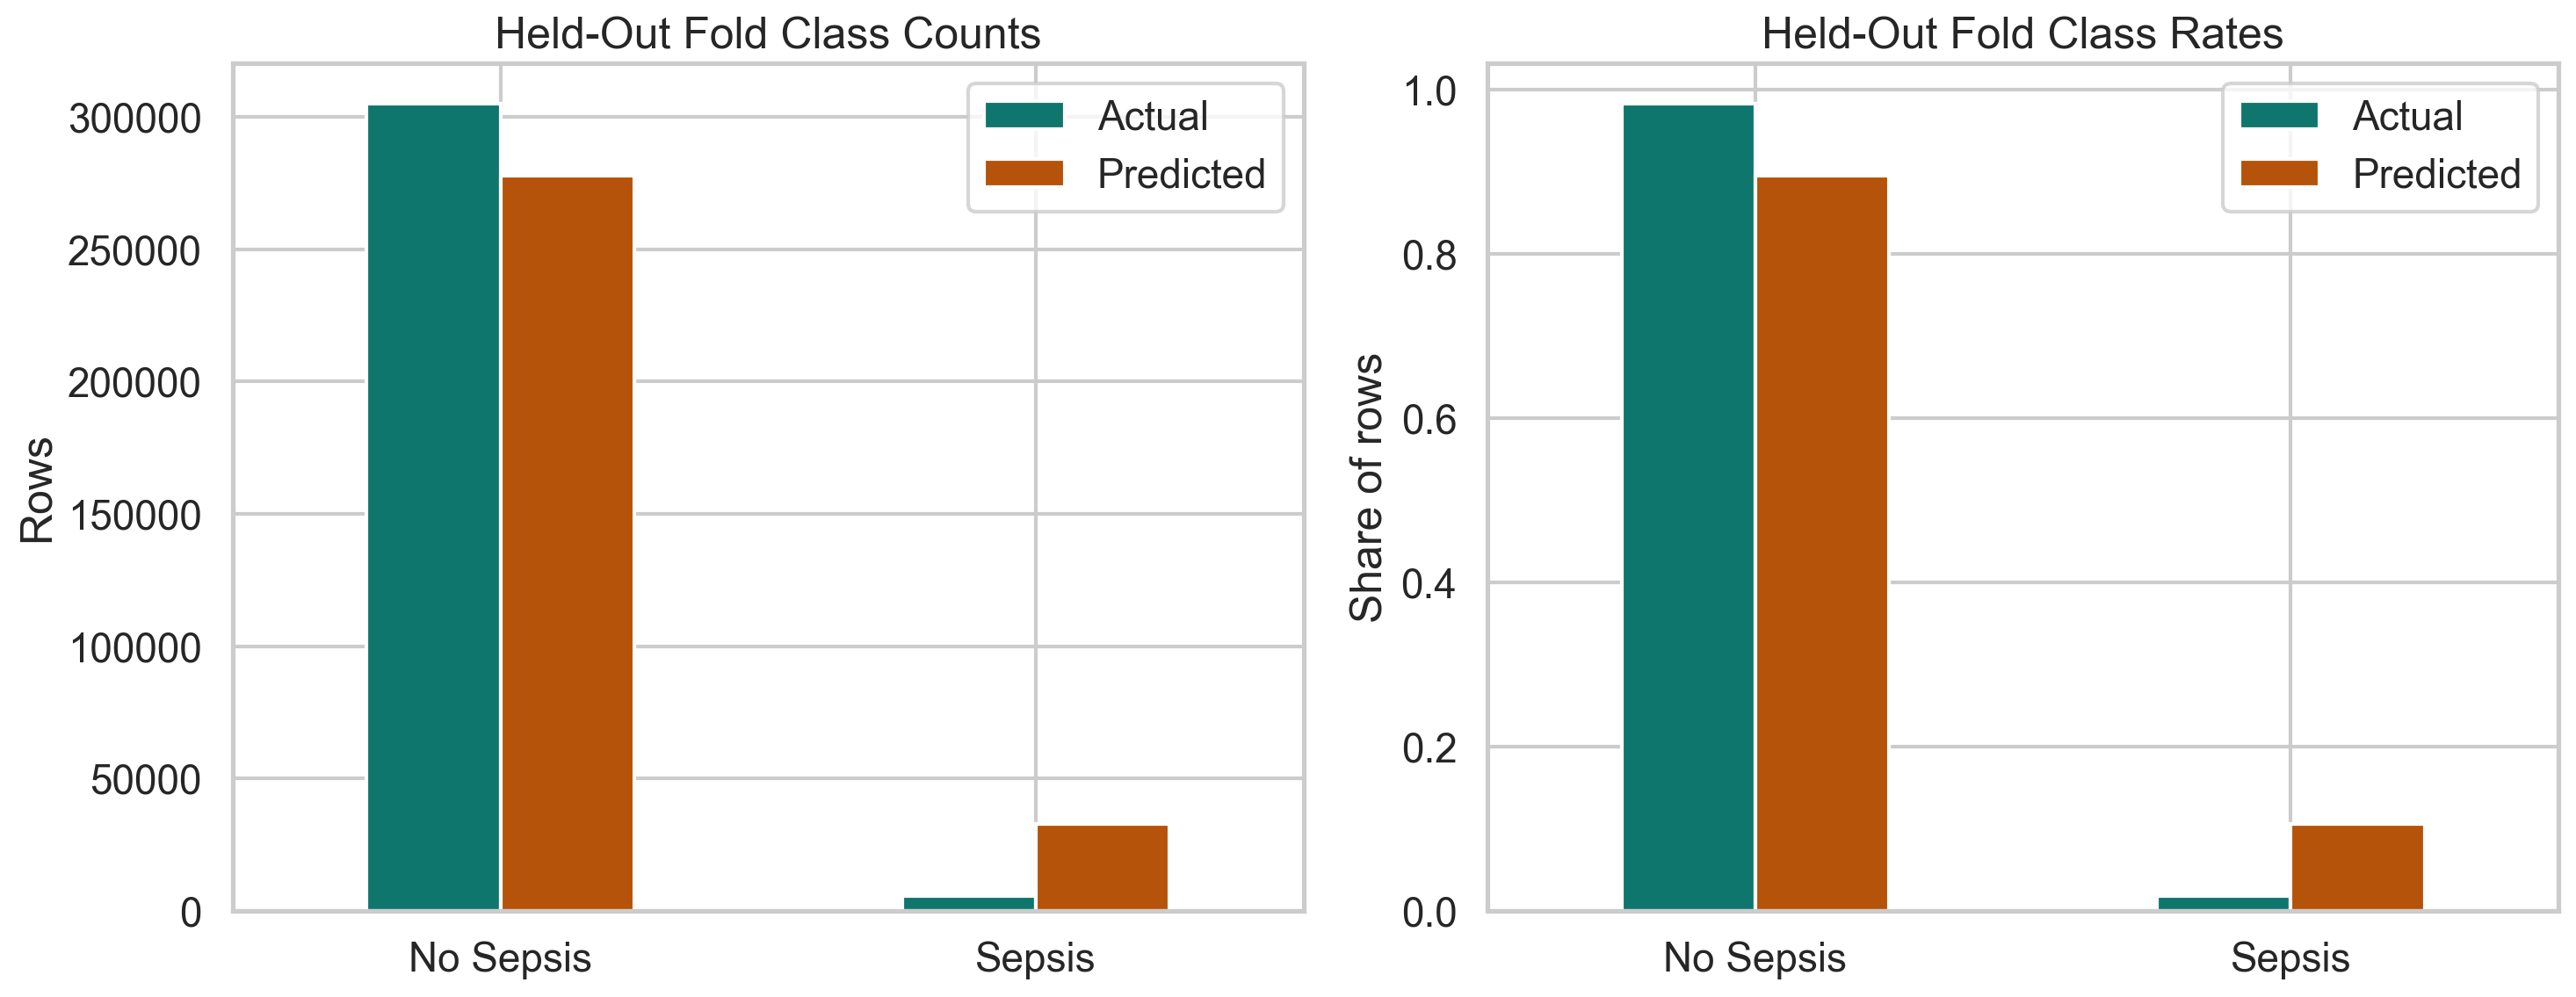

### 02 Confusion Matrices

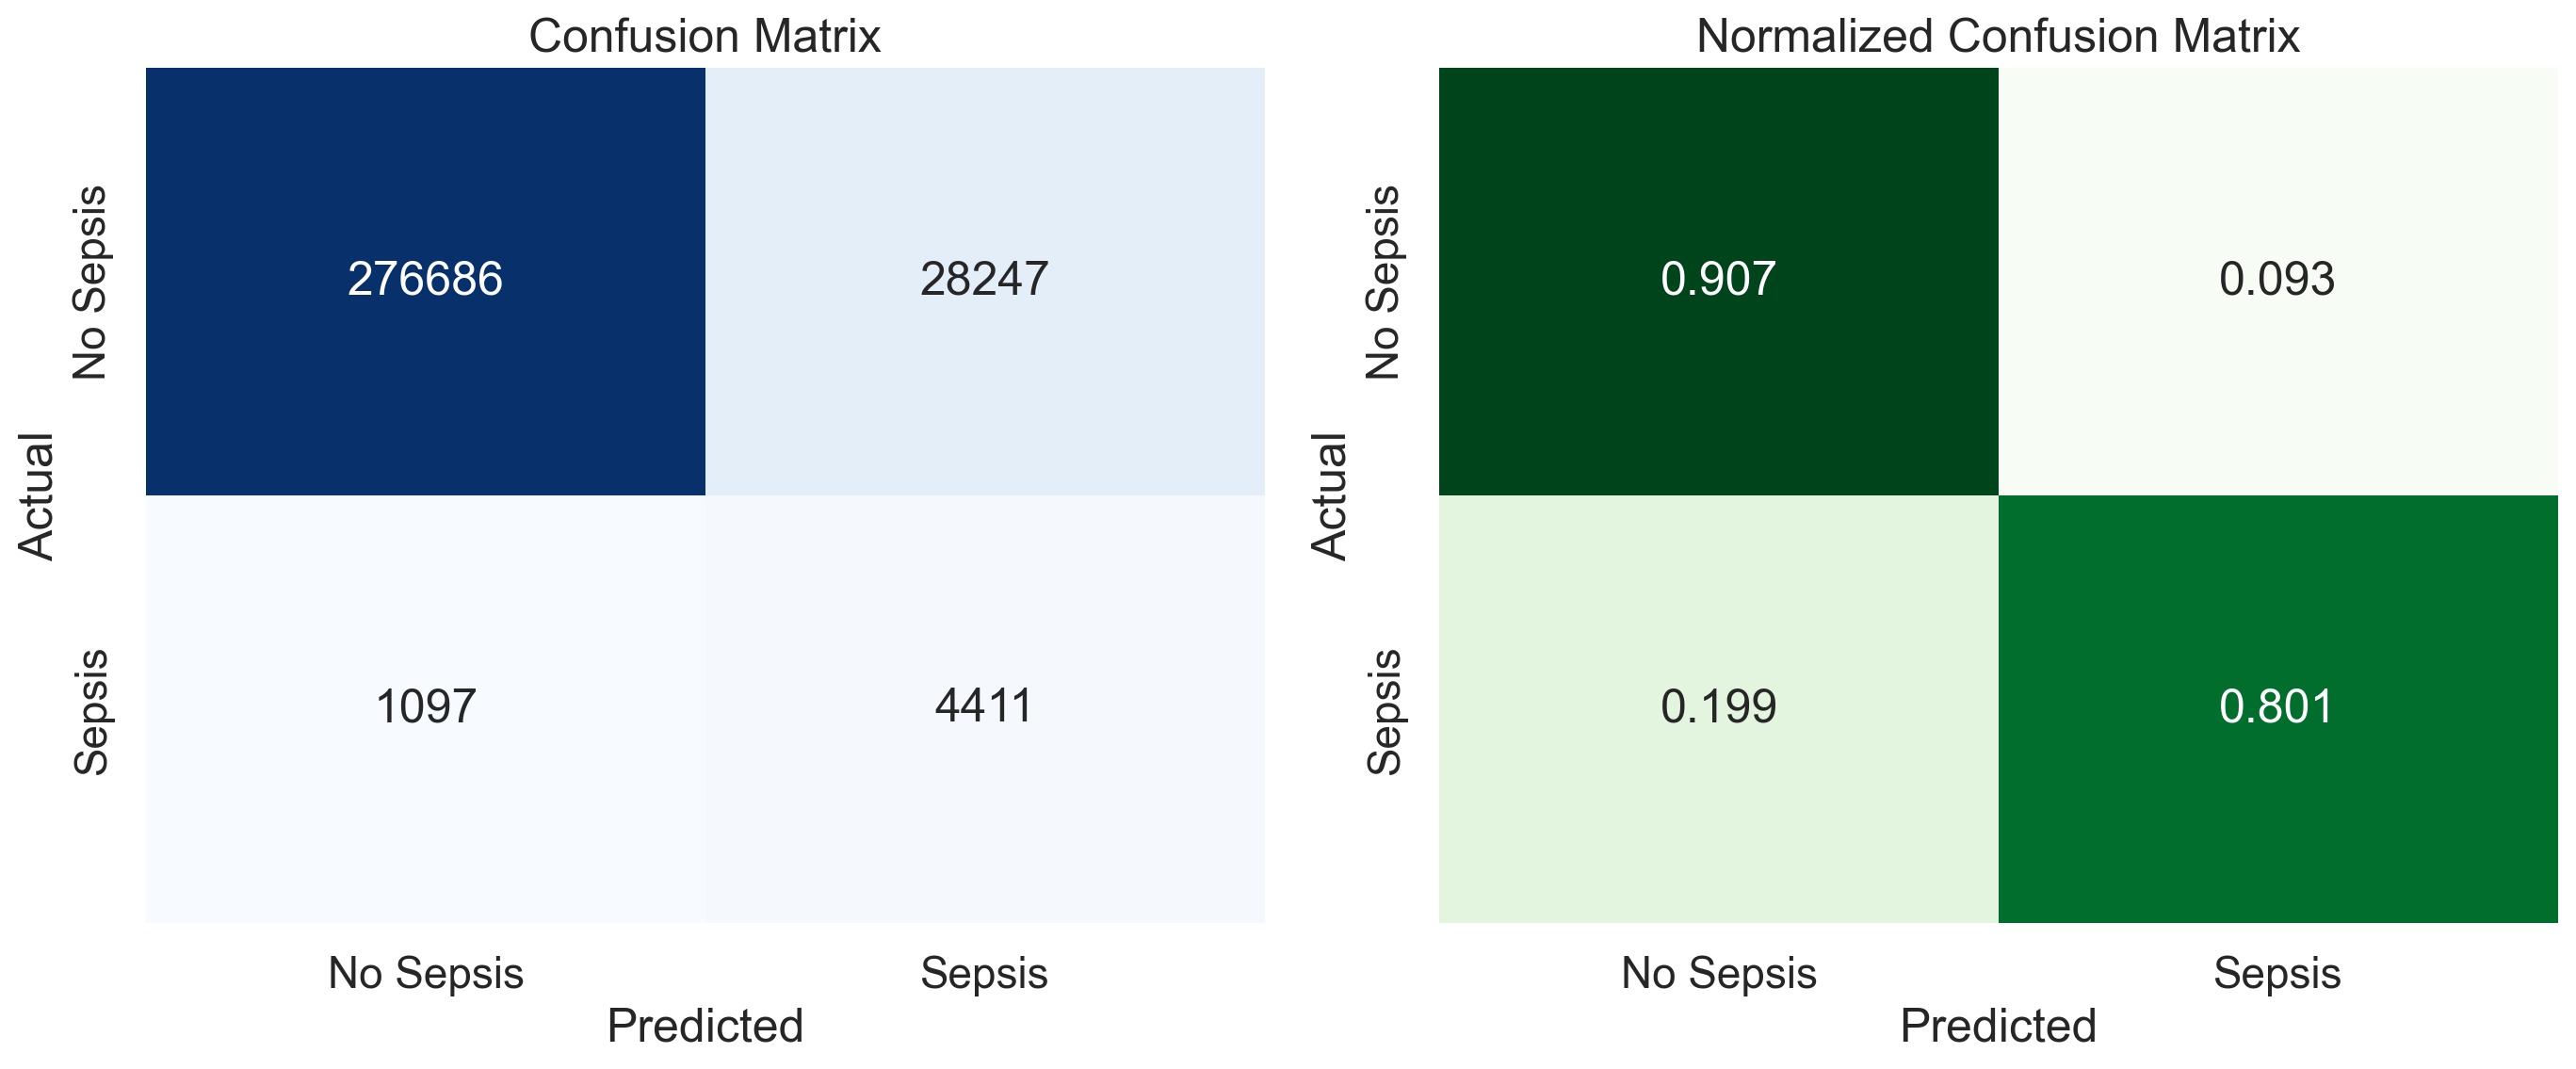

### 03 Roc And Precision Recall Curves

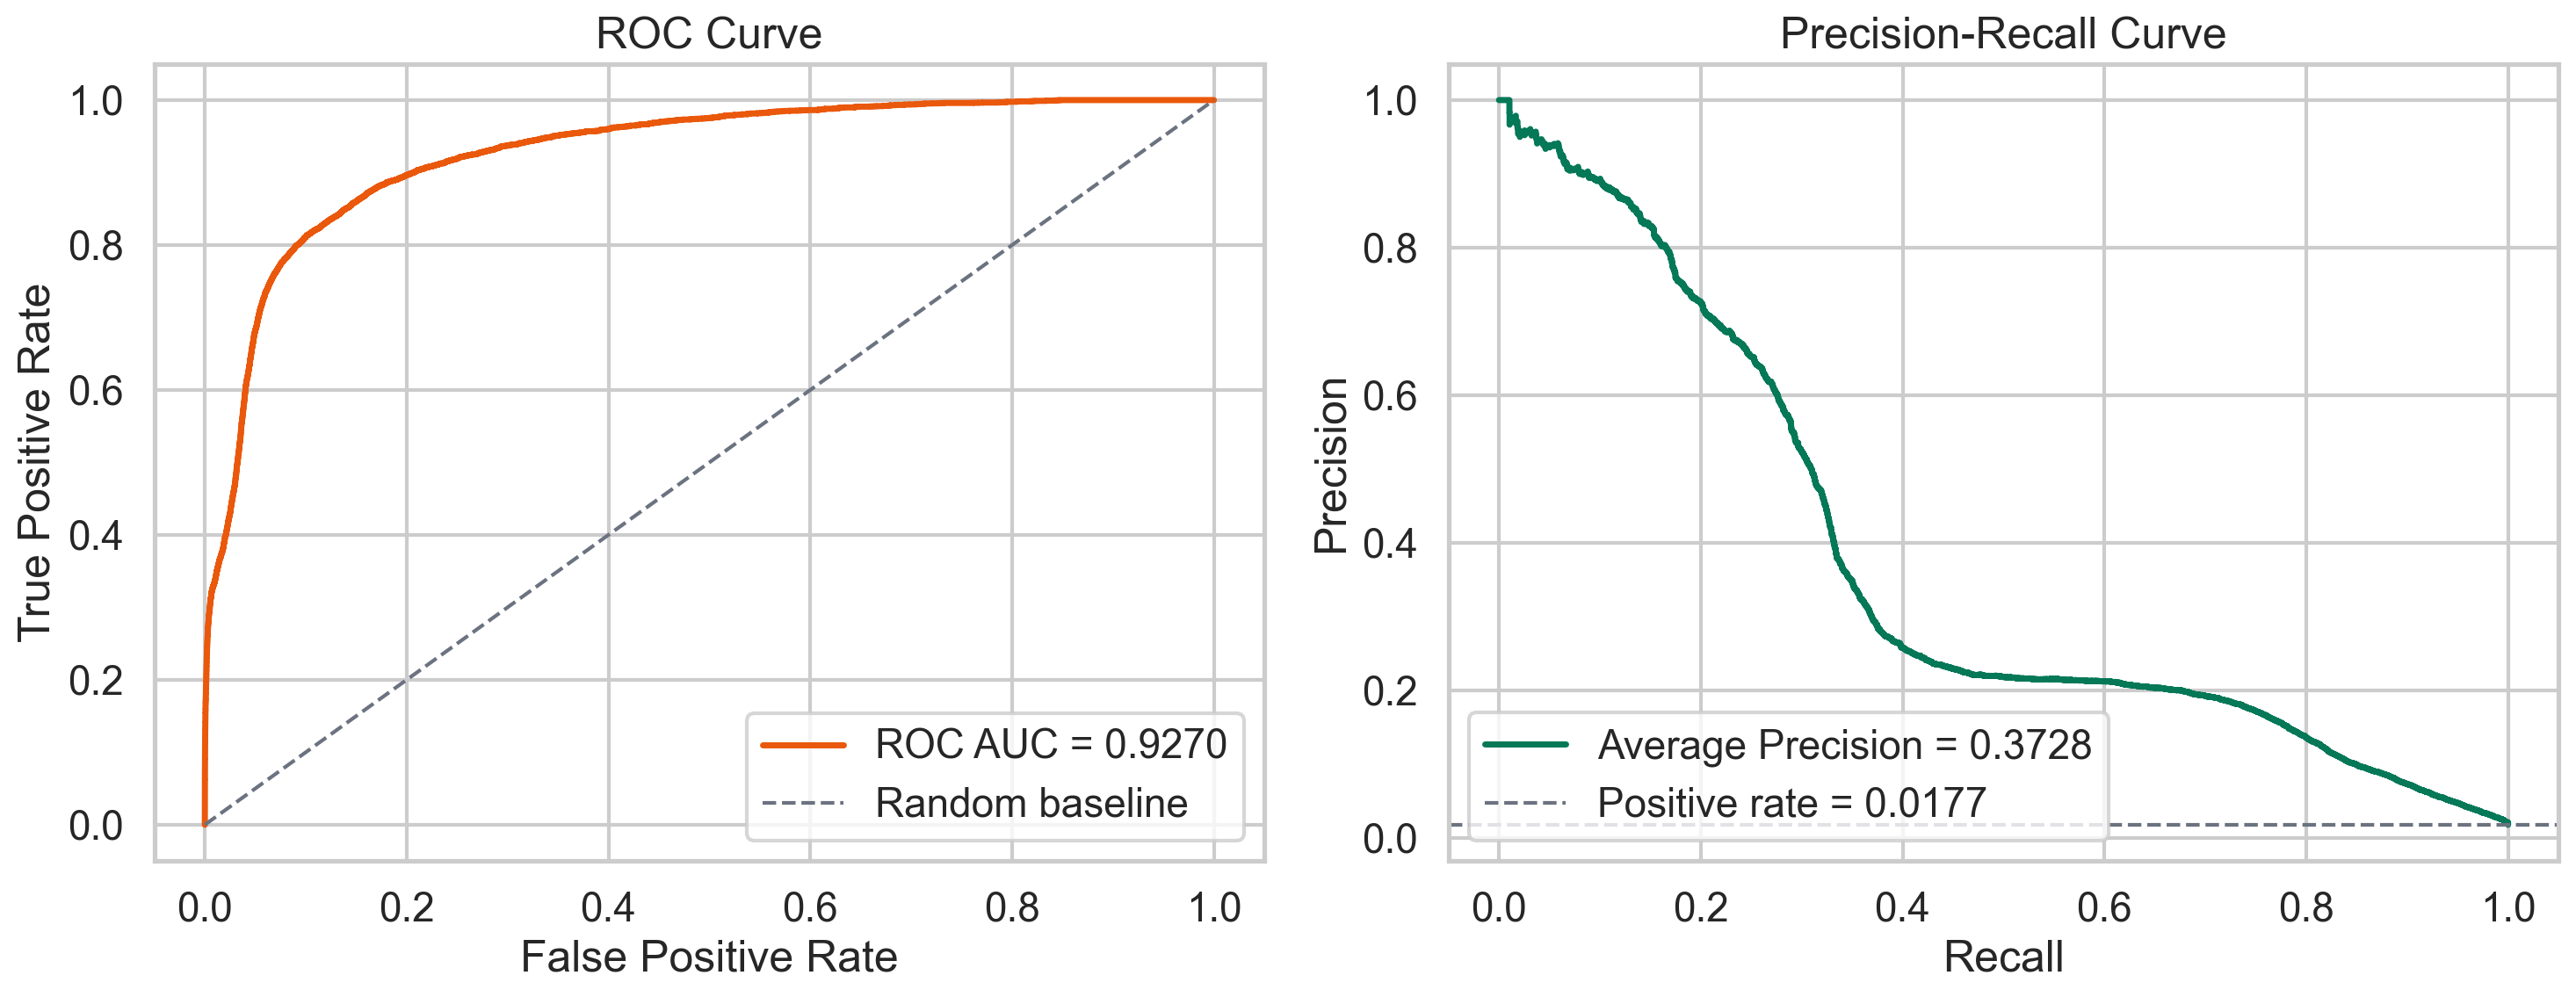

### 04 Probability Distribution And Calibration

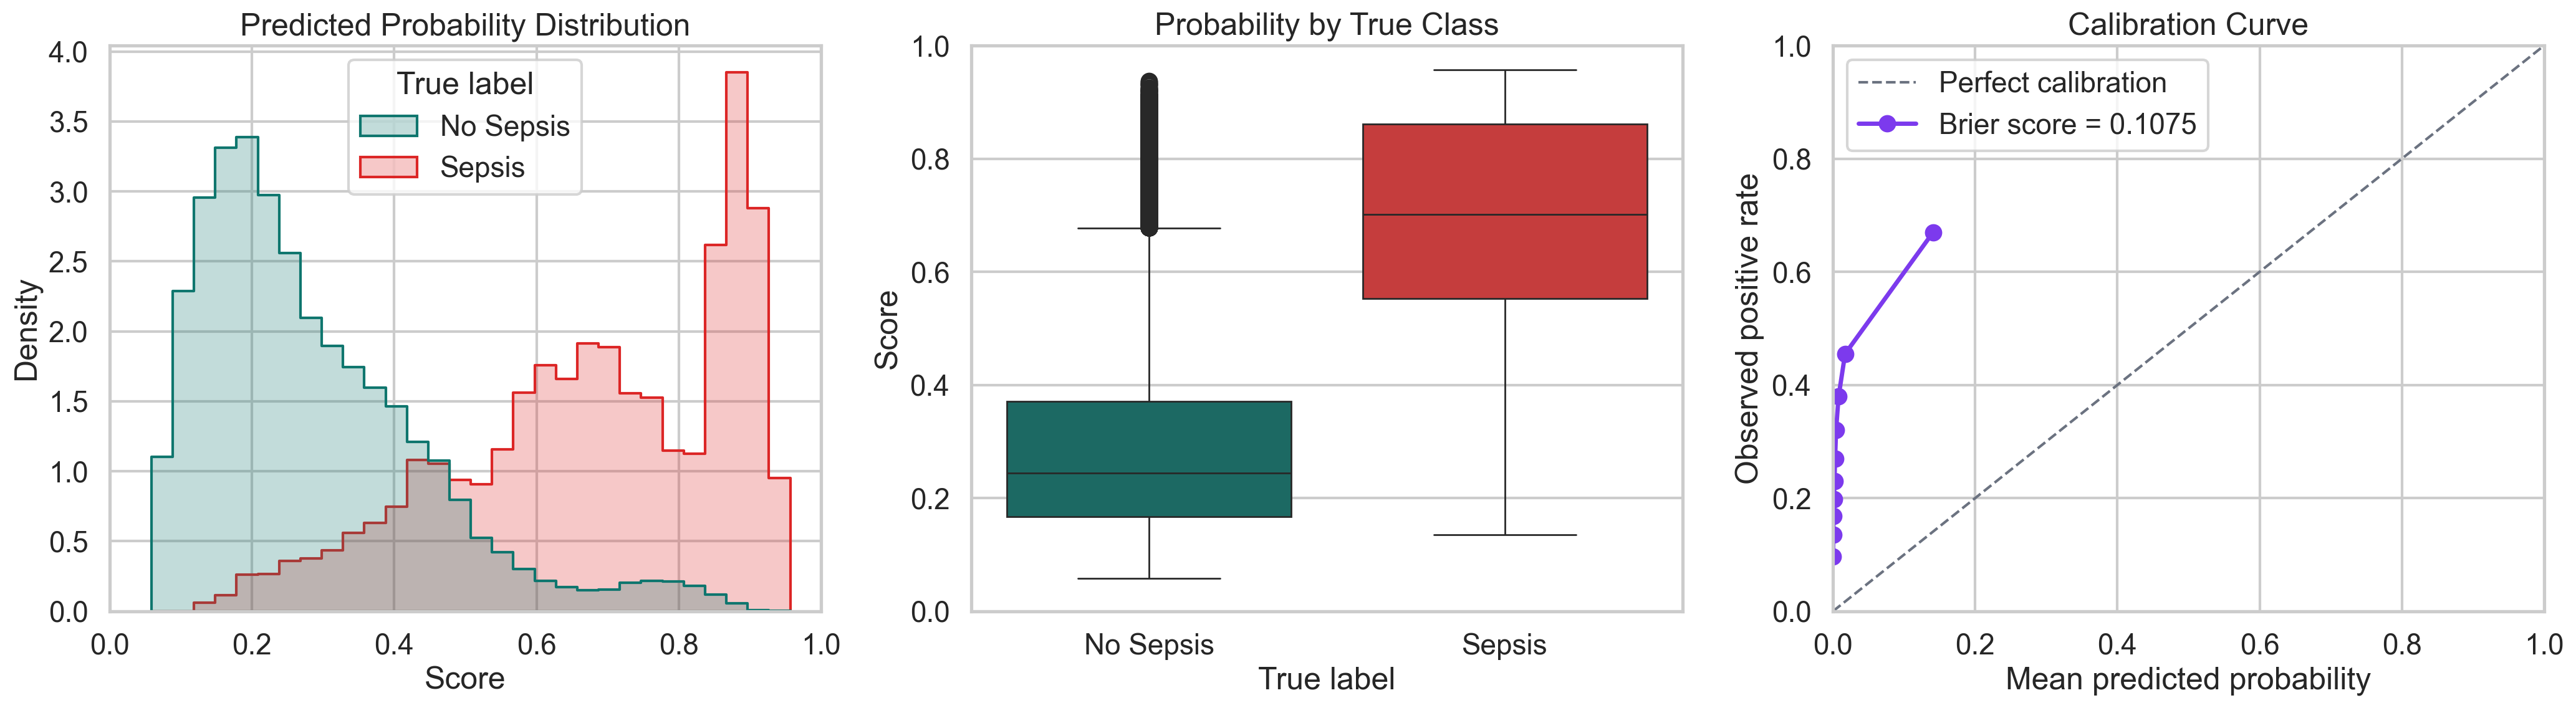

### 05 Threshold Gain Lift And Ks Curves

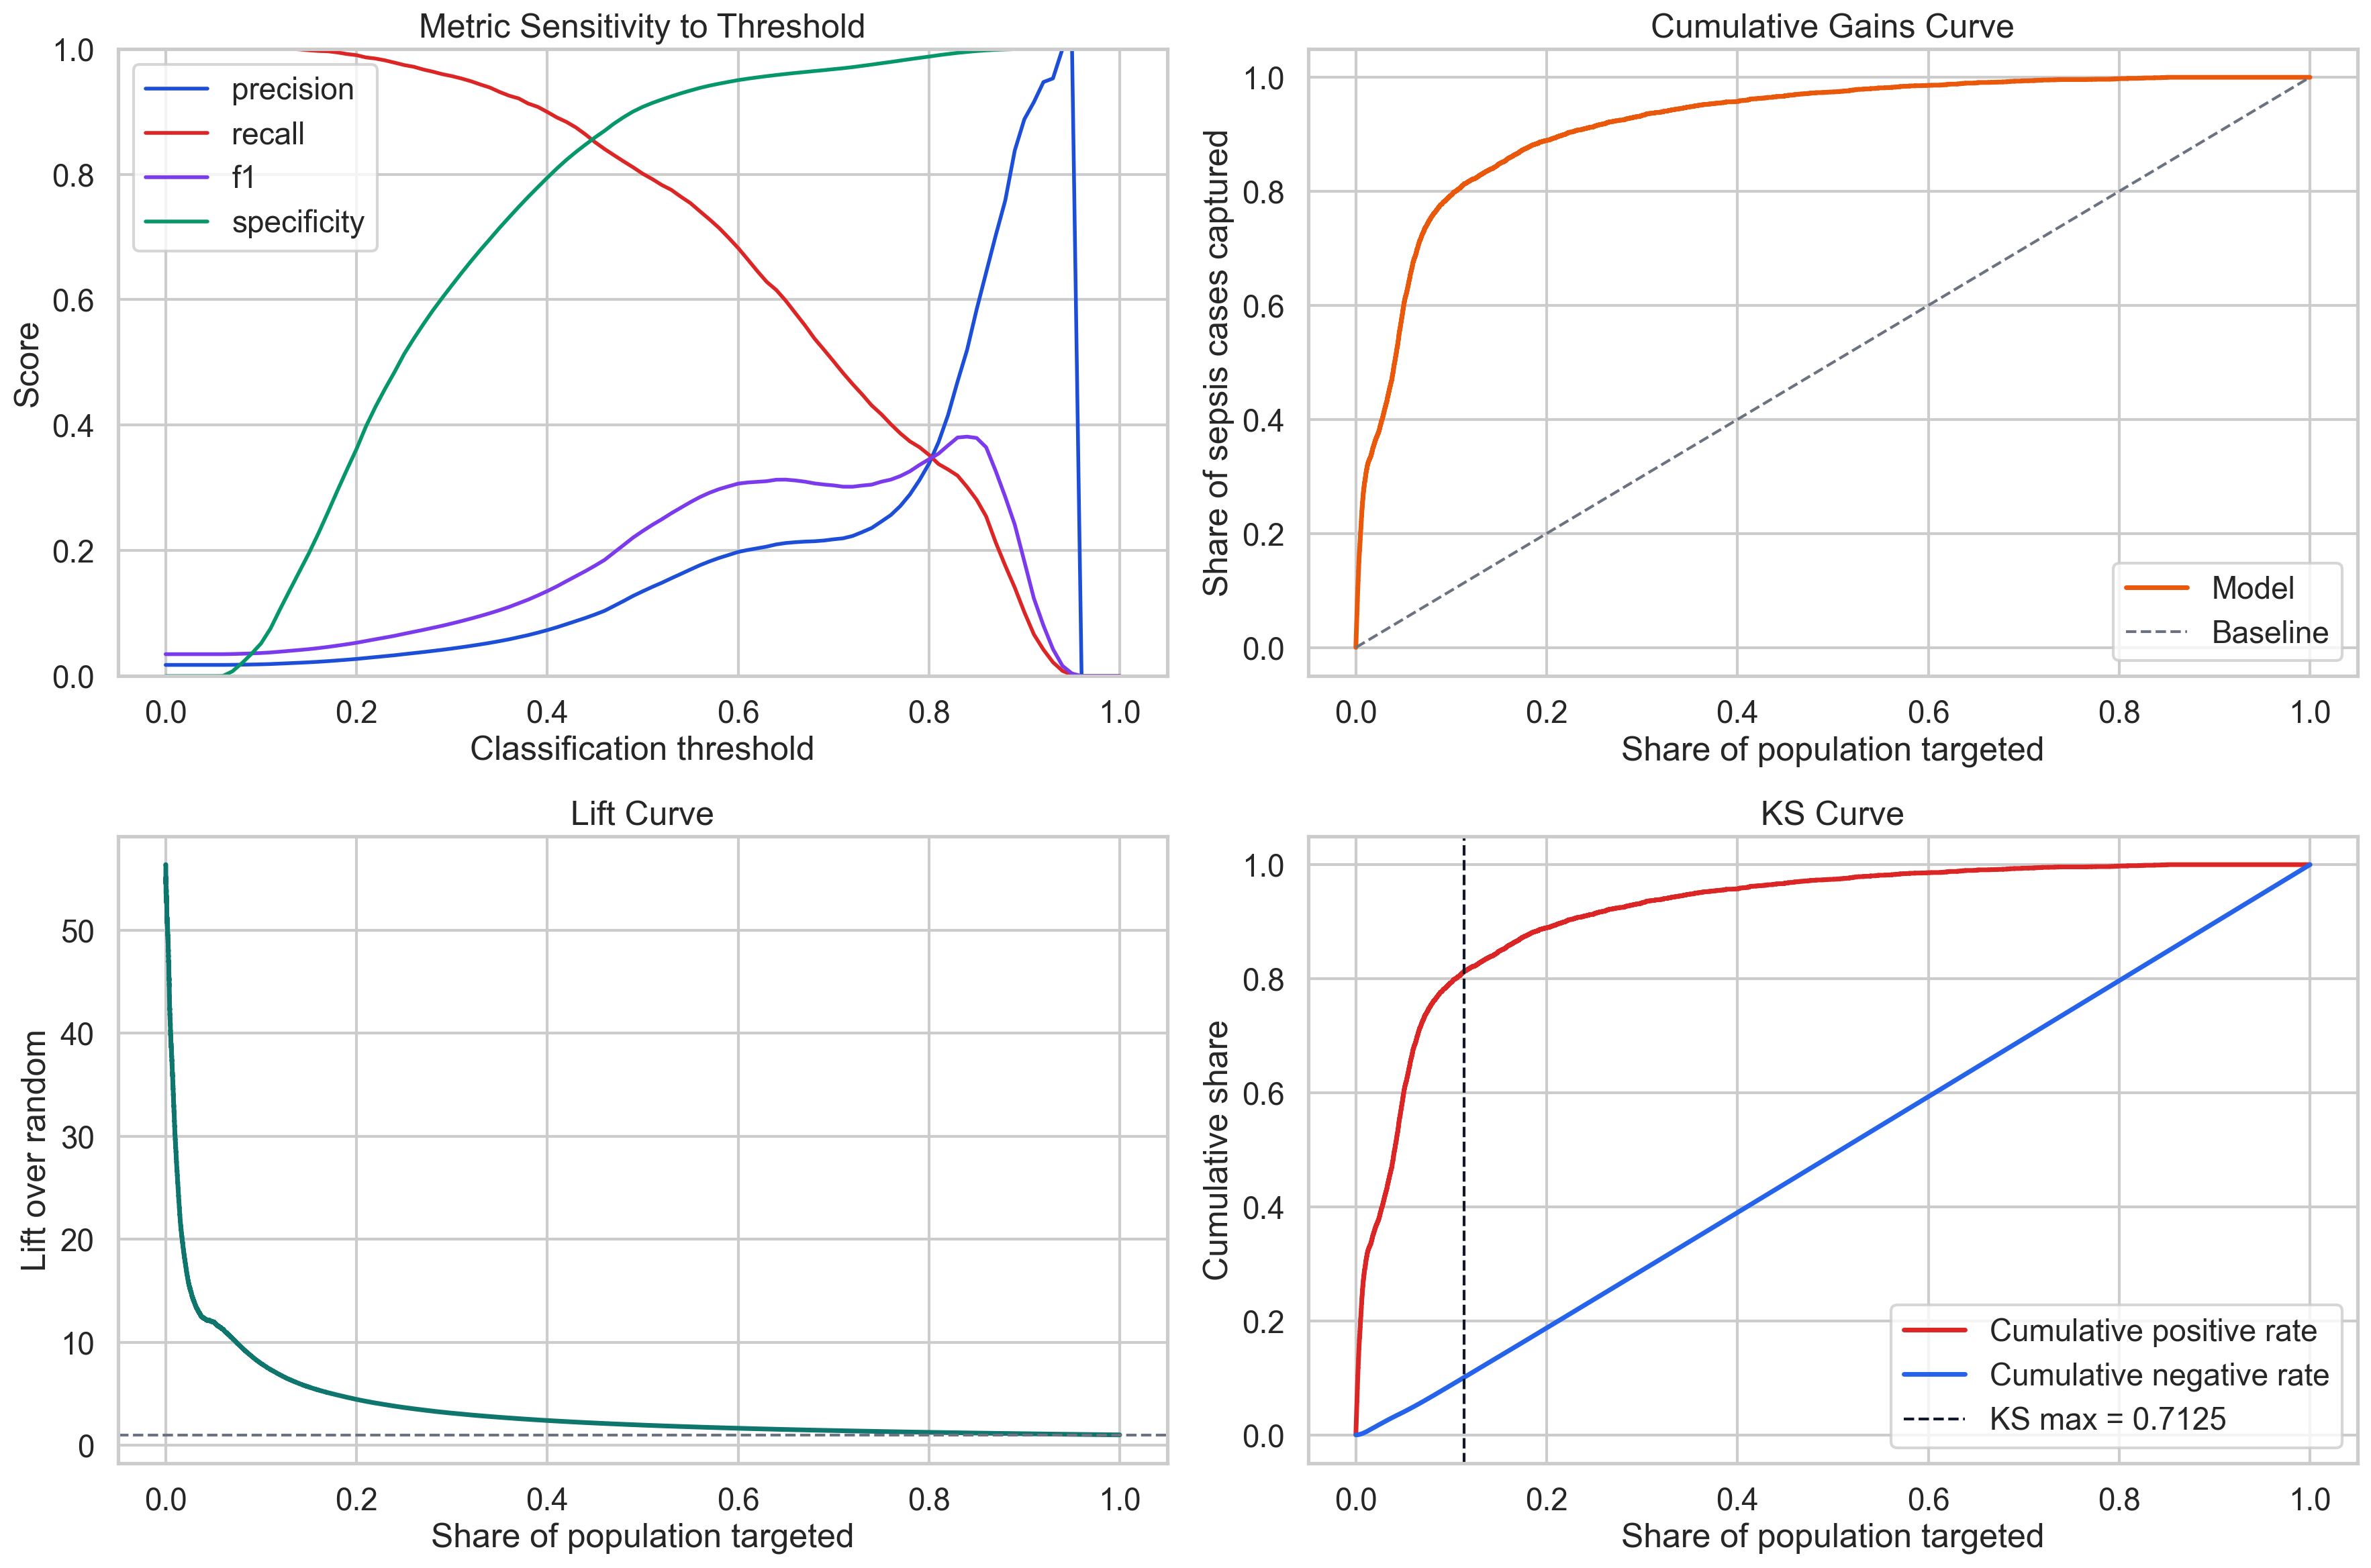

### 06 Feature Importance And Cumulative Importance

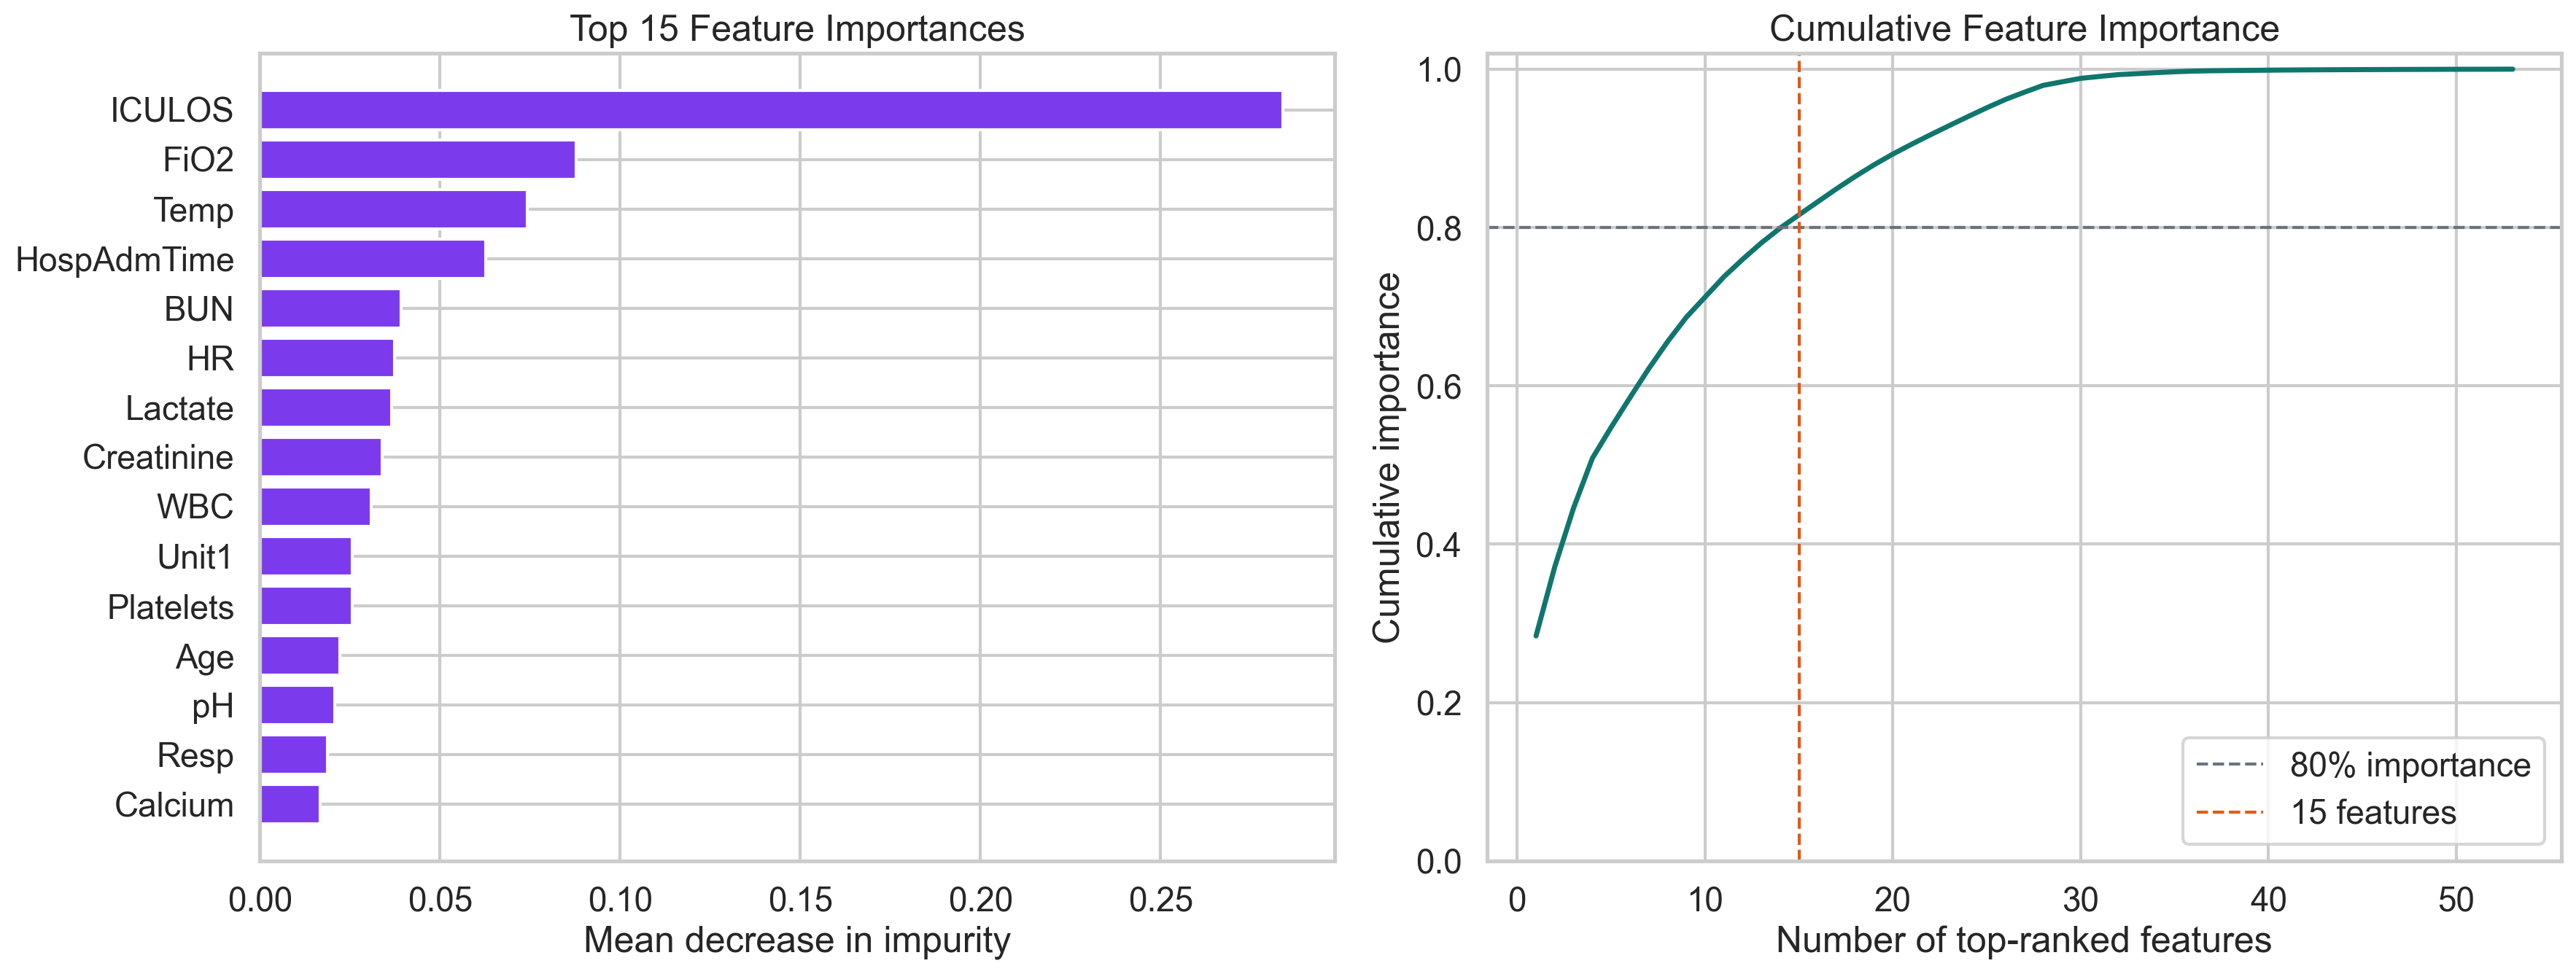

### 09 Sample Tree From Random Forest

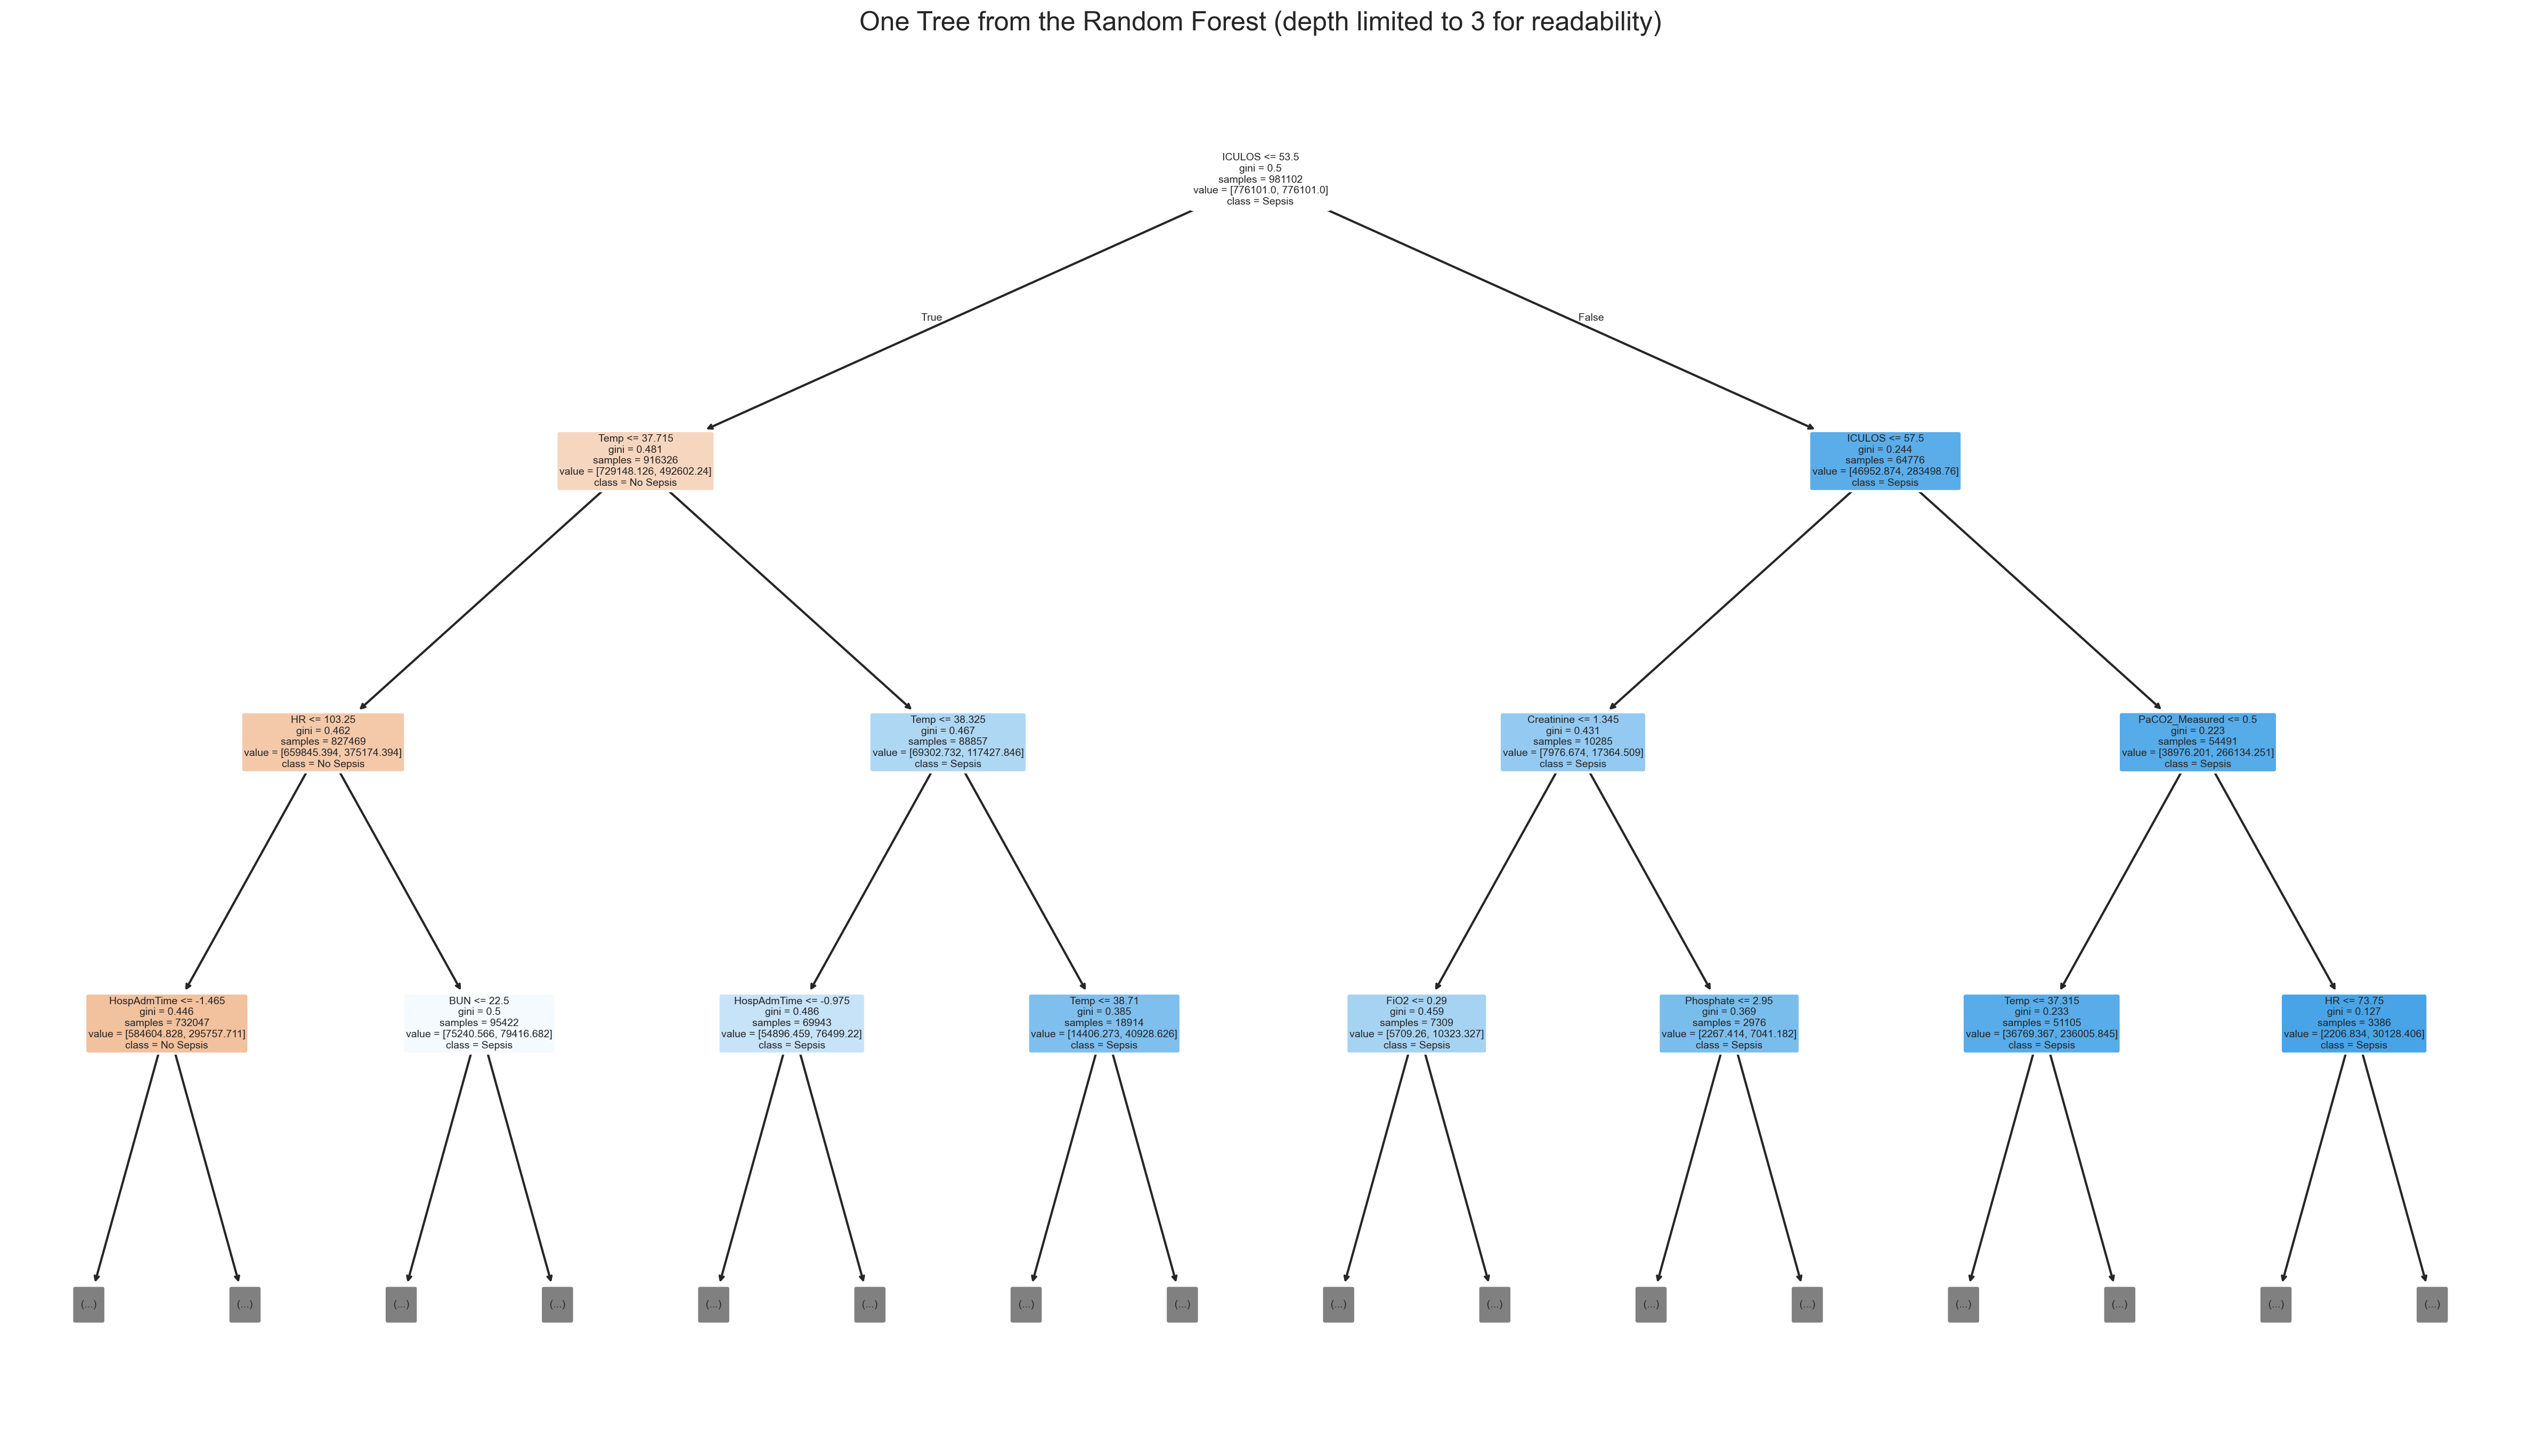

### 07 Permutation Importance

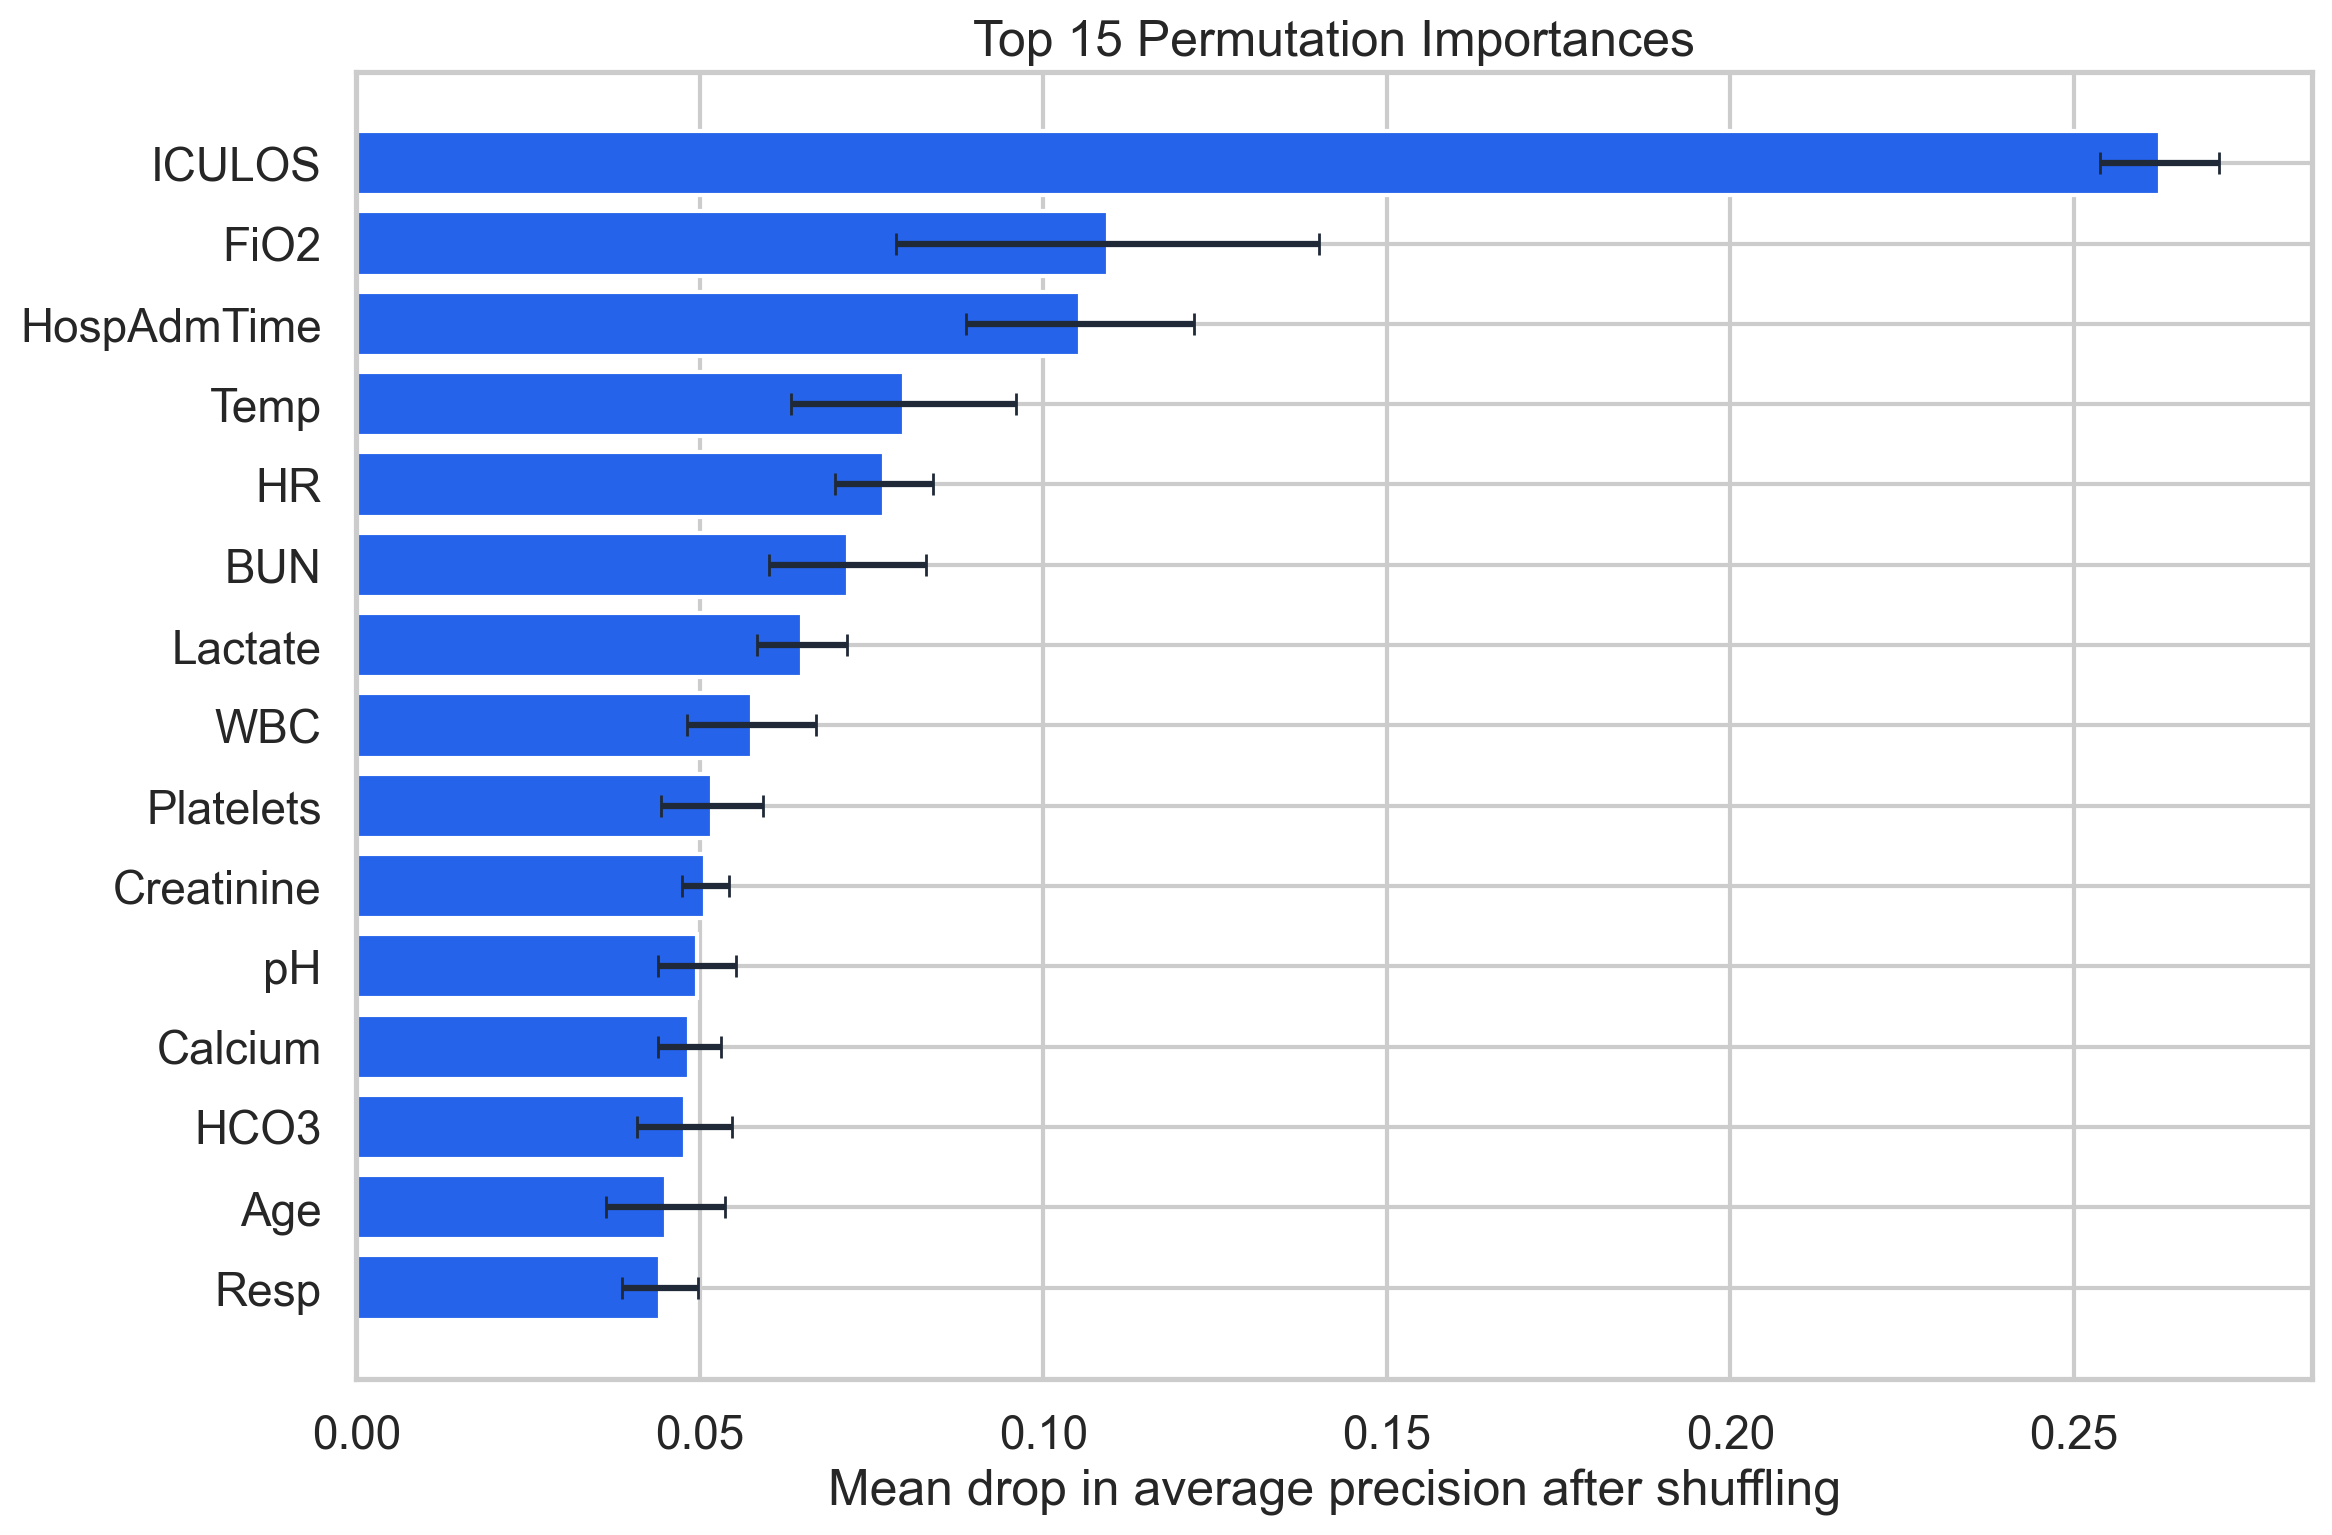

### 08 Partial Dependence Top Features

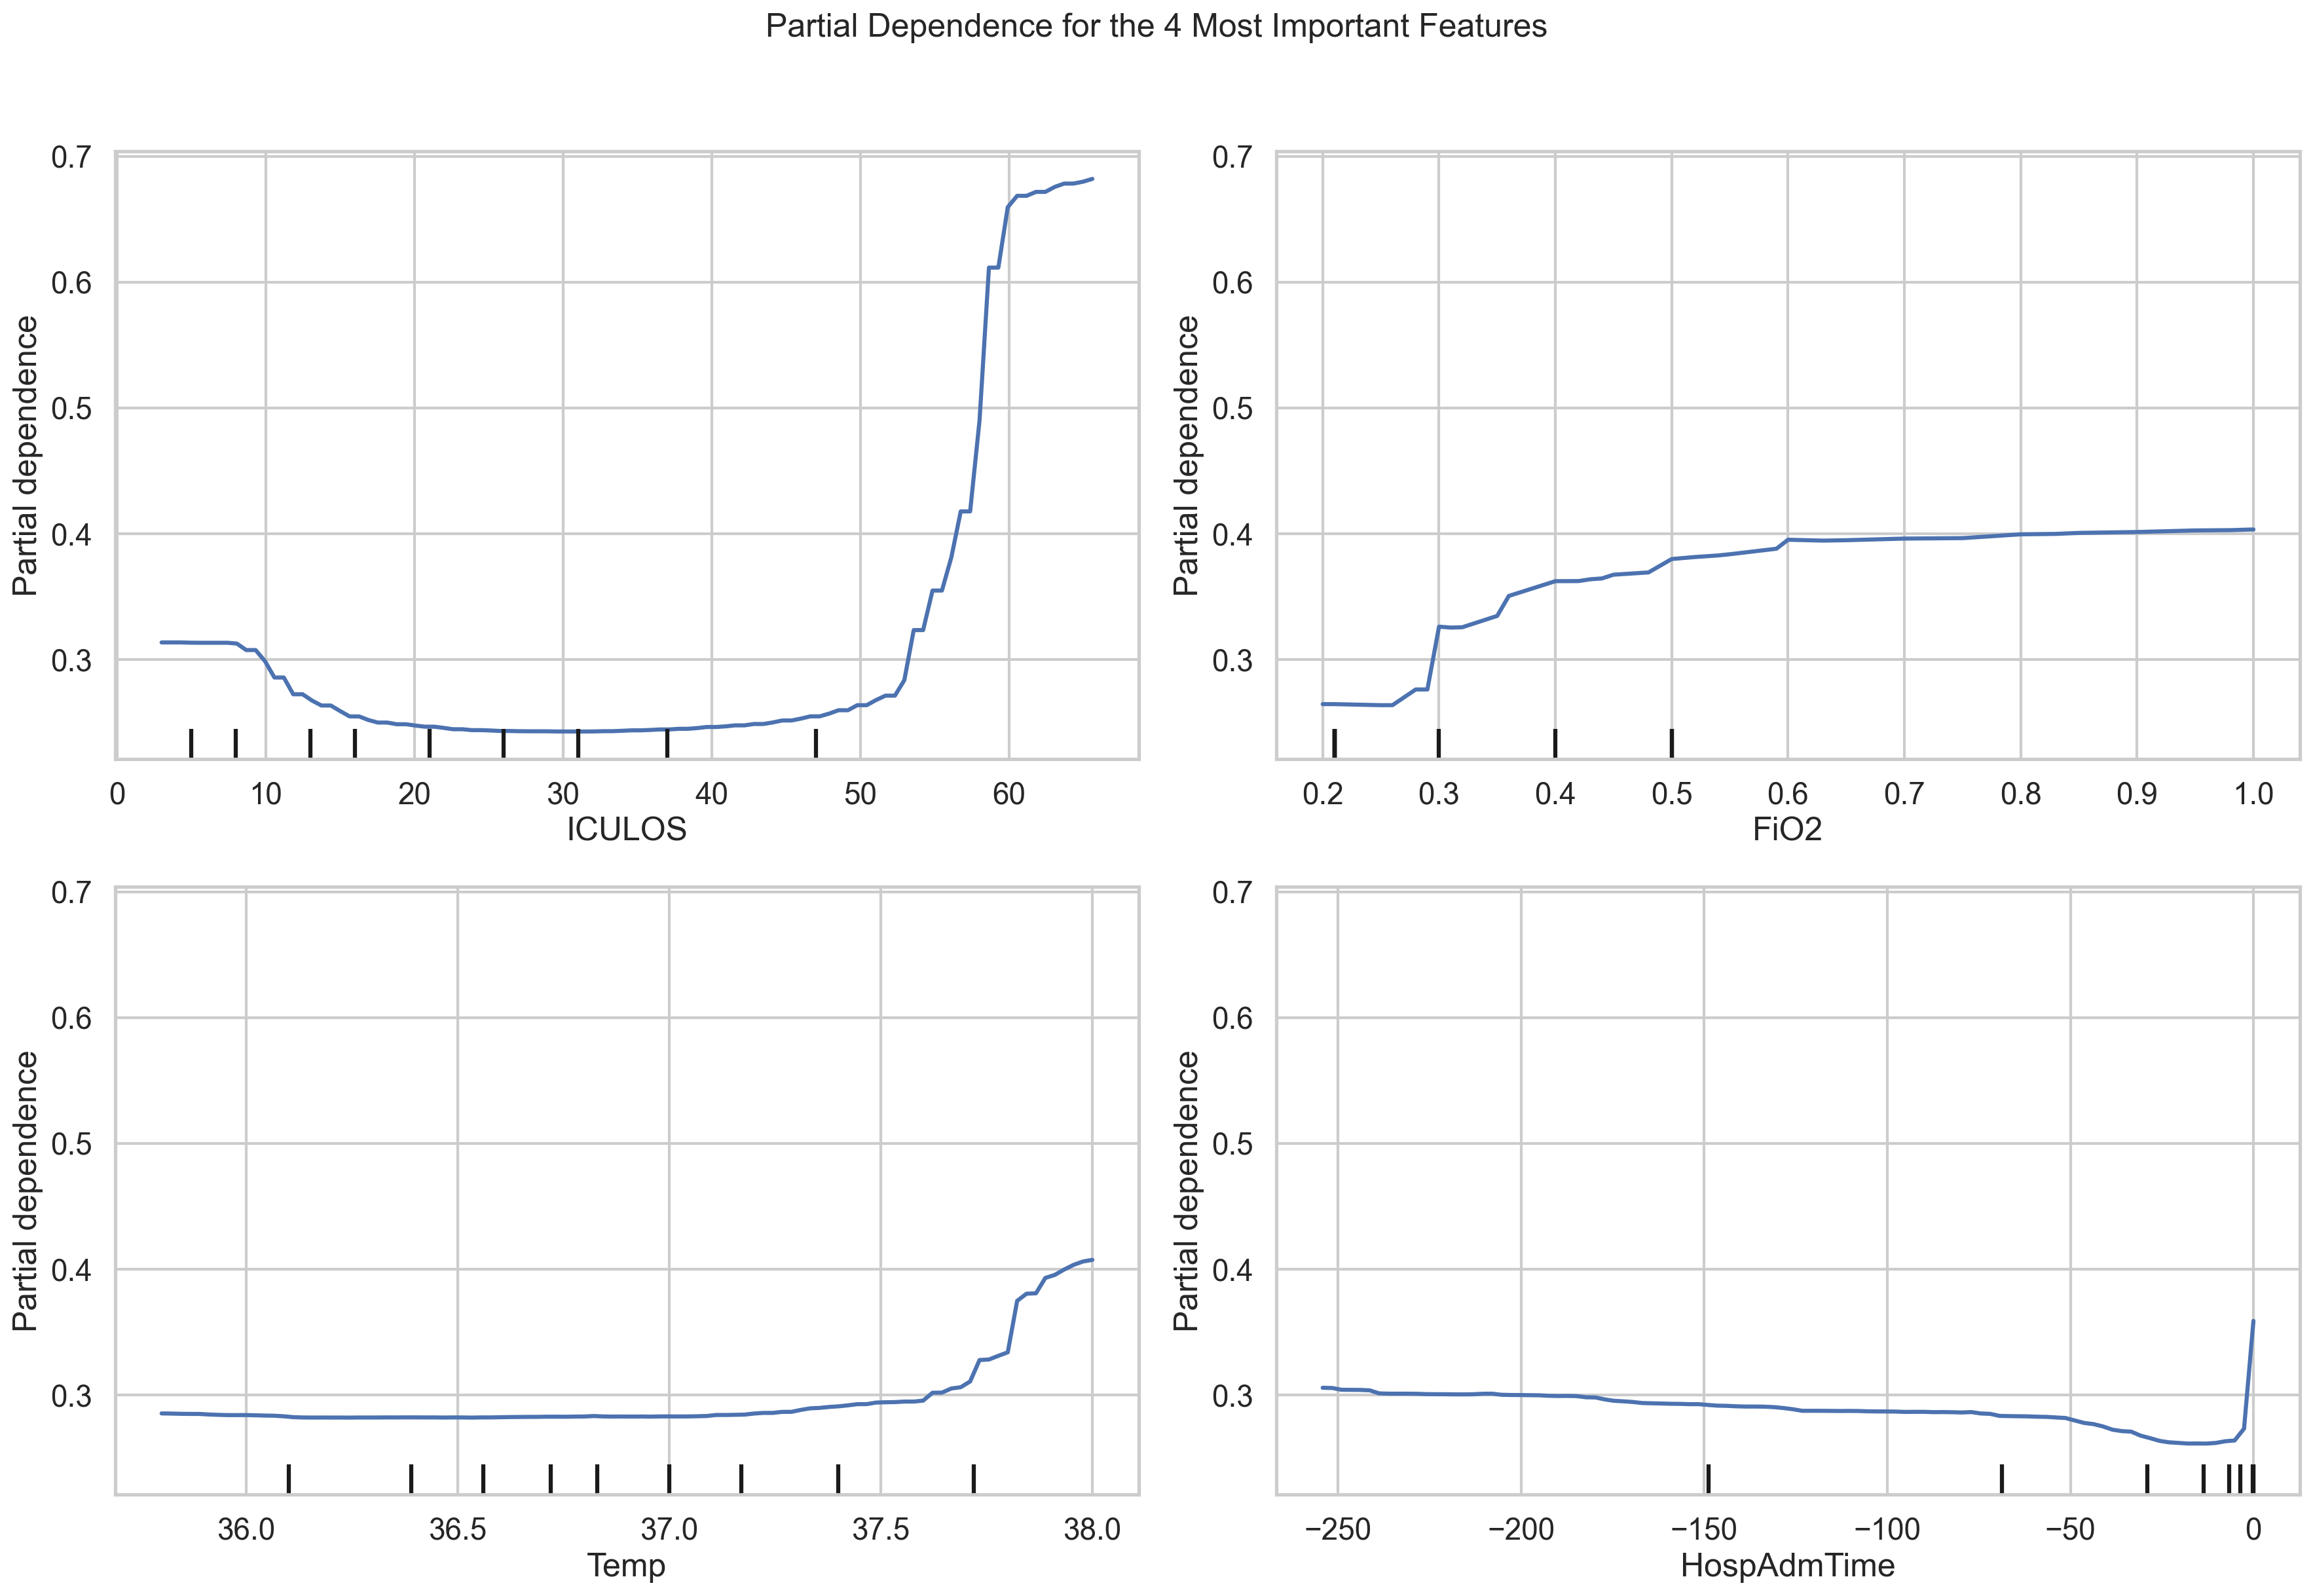

In [3]:
display(Markdown("## Saved Figures"))

for figure_path in output["figure_paths"]:
    figure_name = Path(figure_path).stem.replace("_", " ").title()
    display(Markdown(f"### {figure_name}"))
    display(Image(filename=figure_path))
